# Identification of CRISPRa positive controls

This notebook contains an analysis of CRISPRa screening data from Sanson et al. 2018, in order to find positive controls for CRISPRa screens.

## Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy
import random
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import gpplot as gpp
import mygene

In [2]:
a375_meljuso_reads_df = pd.read_excel('data/Sanson2018_Calabrese_reads_A375_MelJuSo.xlsx', header=0) # from Sanson et al. 2018
a549_hct116_reads_df = pd.read_csv('data/Sanson2018_Calabrese_reads_A549_HCT116.csv', header=0) # unpublished
annotation_file = pd.read_csv('data/adhoc_sgRNA_disco_GRCh38_Ensembl_SpyoCas9A_strict.csv')

# for validation of candidates
stop_and_go_gene_list = pd.read_excel('data/Sack2018_ORF_data.xlsx', sheet_name = 'S2D', header = 2) # from Sack et al. 2018

/Users/lierika/screen_analysis/lib/python3.9/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
# cleaning column names
header_rows = a375_meljuso_reads_df.iloc[0:3] # join first three rows into combined cell line, drug type, replicate names
new_columns = [
    "_".join(str(val) for val in col_values if pd.notna(val))
    for col_values in header_rows.values.T
]
a375_meljuso_reads_df.columns = new_columns
a375_meljuso_reads_df = a375_meljuso_reads_df.drop(index=[0,1,2]).reset_index(drop=True)
a375_meljuso_reads_df = a375_meljuso_reads_df.rename(columns={'pDNA_pDNA_pDNA':'A375_meljuso_pDNA'}) # clean pDNA col name

In [4]:
a375_meljuso_reads_df = a375_meljuso_reads_df[['sgRNA Sequence', 'A375_meljuso_pDNA', 'A375_no drug_RepA', 'A375_no drug_RepB',
       'Meljuso_no drug_RepA', 'Meljuso_no drug_RepB']] # only care about viability screens not drug screens
a375_meljuso_reads_df

,sgRNA Sequence,A375_meljuso_pDNA,A375_no drug_RepA,A375_no drug_RepB,Meljuso_no drug_RepA,Meljuso_no drug_RepB
0,AAAAAAAAAAAGCACTCTGT,17,230,1069,95,118
1,AAAAAAAAAAGCAGTGGGAG,20,539,332,57,15
2,AAAAAAAAAAGGTCATTCAG,24,449,556,171,136
3,AAAAAAAAAATGTCAGAAGC,29,383,727,153,120
4,AAAAAAAAACAGGTCACCCA,29,426,267,118,125
...,...,...,...,...,...,...
56757,TTTGTTTGCTTCGAGGACGA,52,908,513,351,242
56758,TTTTACCTTGTTCACATGGA,47,1527,2150,239,190
56759,TTTTGACTCTAATCACCGGT,41,872,731,269,260
56760,TTTTTAATACAAGGTAATCT,28,426,527,205,170


In [5]:
a549_hct116_reads_df = a549_hct116_reads_df[['Construct Barcode', 'A549;XPR_109;CP0052;D21;RepA;Dropout',
       'A549;XPR_109;CP0052;D21;RepB;Dropout',
       'HCT116;XPR_109;CP0052;D21;RepA;Dropout',
       'HCT116;XPR_109;CP0052;D21;RepB;Dropout','pDNA']] # keep viability screen columns

In [6]:
a549_hct116_reads_df = a549_hct116_reads_df.rename(columns={'pDNA':'A549_hct116_pDNA',
                                                            'A549;XPR_109;CP0052;D21;RepA;Dropout' : "A549_no drug_RepA",
                                                            'A549;XPR_109;CP0052;D21;RepB;Dropout' : "A549_no drug_RepB",
                                                            'HCT116;XPR_109;CP0052;D21;RepA;Dropout': "Hct116_no drug_RepA",
                                                            'HCT116;XPR_109;CP0052;D21;RepB;Dropout': "Hct116_no drug_RepB",
                                                           'Construct Barcode':'sgRNA Sequence'}) # clean names

a549_hct116_reads_df                                           

,sgRNA Sequence,A549_no drug_RepA,A549_no drug_RepB,Hct116_no drug_RepA,Hct116_no drug_RepB,A549_hct116_pDNA
0,AAAAAAAAAAAGCACTCTGT,209,260,163,60,43
1,AAAAAAAAAAGCAGTGGGAG,457,443,142,192,37
2,AAAAAAAAAAGGTCATTCAG,303,398,127,277,56
3,AAAAAAAAAATGTCAGAAGC,338,426,205,237,77
4,AAAAAAAAACAGGTCACCCA,571,595,154,310,73
...,...,...,...,...,...,...
56757,TTTGTTTGCTTCGAGGACGA,509,772,648,567,126
56758,TTTTACCTTGTTCACATGGA,805,834,905,855,145
56759,TTTTGACTCTAATCACCGGT,679,650,724,487,113
56760,TTTTTAATACAAGGTAATCT,501,444,396,504,91


In [7]:
set(a549_hct116_reads_df['sgRNA Sequence']) == set(a375_meljuso_reads_df['sgRNA Sequence']) # guides match for both sets                                         

True

In [8]:
reads_df = pd.merge(a375_meljuso_reads_df,a549_hct116_reads_df, on = "sgRNA Sequence") # merge read dfs together
reads_df

,sgRNA Sequence,A375_meljuso_pDNA,A375_no drug_RepA,A375_no drug_RepB,Meljuso_no drug_RepA,Meljuso_no drug_RepB,A549_no drug_RepA,A549_no drug_RepB,Hct116_no drug_RepA,Hct116_no drug_RepB,A549_hct116_pDNA
0,AAAAAAAAAAAGCACTCTGT,17,230,1069,95,118,209,260,163,60,43
1,AAAAAAAAAAGCAGTGGGAG,20,539,332,57,15,457,443,142,192,37
2,AAAAAAAAAAGGTCATTCAG,24,449,556,171,136,303,398,127,277,56
3,AAAAAAAAAATGTCAGAAGC,29,383,727,153,120,338,426,205,237,77
4,AAAAAAAAACAGGTCACCCA,29,426,267,118,125,571,595,154,310,73
...,...,...,...,...,...,...,...,...,...,...,...
56757,TTTGTTTGCTTCGAGGACGA,52,908,513,351,242,509,772,648,567,126
56758,TTTTACCTTGTTCACATGGA,47,1527,2150,239,190,805,834,905,855,145
56759,TTTTGACTCTAATCACCGGT,41,872,731,269,260,679,650,724,487,113
56760,TTTTTAATACAAGGTAATCT,28,426,527,205,170,501,444,396,504,91


In [9]:
annotation_file = annotation_file[['Target Sequence','On-target Gene IDs', 'Notes']] # keep only sequence, ENSEMBL gene ID, and notes columns

In [10]:
annotation_file

,Target Sequence,On-target Gene IDs,Notes
0,AAAAAAAAAAAGCACTCTGT,"ENSG00000256061,ENSG00000261771",NaN
1,AAAAAAAAAAGCAGTGGGAG,ENSG00000205221,NaN
2,AAAAAAAAAAGGTCATTCAG,ENSG00000180433,NaN
3,AAAAAAAAAATGTCAGAAGC,ENSG00000129437,NaN
4,AAAAAAAAACAGGTCACCCA,ENSG00000152822,NaN
...,...,...,...
56757,TTTGTTTGCTTCGAGGACGA,ENSG00000267909,NaN
56758,TTTTACCTTGTTCACATGGA,NaN,INACTIVE_4T; ONE_INTERGENIC_SITE
56759,TTTTGACTCTAATCACCGGT,NaN,INACTIVE_4T; NO_SITE (4 zeros)
56760,TTTTTAATACAAGGTAATCT,NaN,INACTIVE_5T; NO_SITE (5 zeros)


In [11]:
# melting df to account for the fact that guides may correspond to multiple gene IDs
# ie. guide|gene1,gene 2 becomes
# guide|gene1
# guide|gene 2

annotation_file = annotation_file.assign(
    # splits by commas and ignores any surrounding whitespace
    Gene_ID=annotation_file['On-target Gene IDs'].str.split(r'\s*,\s*')
).explode('Gene_ID')

# some of the on-target gene IDs end in commas (ie. "ENSG00000256061,ENSG00000261771, " )
# this leads to incorrect splitting into blank Gene_ID values, which need to be removed
annotation_file = annotation_file[annotation_file['Gene_ID'] != ""]

In [12]:
annotation_file

,Target Sequence,On-target Gene IDs,Notes,Gene_ID
0,AAAAAAAAAAAGCACTCTGT,"ENSG00000256061,ENSG00000261771",NaN,ENSG00000256061
0,AAAAAAAAAAAGCACTCTGT,"ENSG00000256061,ENSG00000261771",NaN,ENSG00000261771
1,AAAAAAAAAAGCAGTGGGAG,ENSG00000205221,NaN,ENSG00000205221
2,AAAAAAAAAAGGTCATTCAG,ENSG00000180433,NaN,ENSG00000180433
3,AAAAAAAAAATGTCAGAAGC,ENSG00000129437,NaN,ENSG00000129437
...,...,...,...,...
56757,TTTGTTTGCTTCGAGGACGA,ENSG00000267909,NaN,ENSG00000267909
56758,TTTTACCTTGTTCACATGGA,NaN,INACTIVE_4T; ONE_INTERGENIC_SITE,NaN
56759,TTTTGACTCTAATCACCGGT,NaN,INACTIVE_4T; NO_SITE (4 zeros),NaN
56760,TTTTTAATACAAGGTAATCT,NaN,INACTIVE_5T; NO_SITE (5 zeros),NaN


In [13]:
annotation_file = annotation_file.drop(columns = "On-target Gene IDs")

In [14]:
# intergenic or no site guides will have NaN for Gene_ID, and instead this info will be indicated in Notes
# guides targeting genes will have NaN in Notes
# if a target sequence has NaN for Gene_ID, put their Notes in the Merged Gene_ID column - otherwise, just put Gene_ID
annotation_file['Merged Gene_ID'] = annotation_file['Notes'].fillna(annotation_file['Gene_ID'])

In [15]:
annotation_file

,Target Sequence,Notes,Gene_ID,Merged Gene_ID
0,AAAAAAAAAAAGCACTCTGT,NaN,ENSG00000256061,ENSG00000256061
0,AAAAAAAAAAAGCACTCTGT,NaN,ENSG00000261771,ENSG00000261771
1,AAAAAAAAAAGCAGTGGGAG,NaN,ENSG00000205221,ENSG00000205221
2,AAAAAAAAAAGGTCATTCAG,NaN,ENSG00000180433,ENSG00000180433
3,AAAAAAAAAATGTCAGAAGC,NaN,ENSG00000129437,ENSG00000129437
...,...,...,...,...
56757,TTTGTTTGCTTCGAGGACGA,NaN,ENSG00000267909,ENSG00000267909
56758,TTTTACCTTGTTCACATGGA,INACTIVE_4T; ONE_INTERGENIC_SITE,NaN,INACTIVE_4T; ONE_INTERGENIC_SITE
56759,TTTTGACTCTAATCACCGGT,INACTIVE_4T; NO_SITE (4 zeros),NaN,INACTIVE_4T; NO_SITE (4 zeros)
56760,TTTTTAATACAAGGTAATCT,INACTIVE_5T; NO_SITE (5 zeros),NaN,INACTIVE_5T; NO_SITE (5 zeros)


In [16]:
annotation_file = annotation_file.drop(columns = ['Notes','Gene_ID'])

In [17]:
# sanity check that the guides match in reads and annotations
set(annotation_file['Target Sequence']) == set(reads_df['sgRNA Sequence']) 

True

## Log normalization

In [18]:
def lognorm(reads):
    """
    Standardize read counts by calculating reads per million,
    adding a pseudo-count of one, and taking the log2

    :param reads: numpy or pandas array
    :returns: numpy or pandas array
    """
    reads_per_million = (reads/reads.sum())*(10**6) 
    lognormed_reads = np.log2(reads_per_million + 1)
    return lognormed_reads

In [19]:
condition_columns = ['A375_meljuso_pDNA', 'A375_no drug_RepA',
       'A375_no drug_RepB', 'Meljuso_no drug_RepA', 'Meljuso_no drug_RepB',
       'A549_no drug_RepA', 'A549_no drug_RepB', 'Hct116_no drug_RepA',
       'Hct116_no drug_RepB', 'A549_hct116_pDNA']
lognorm_df = reads_df.copy()
lognorm_df[condition_columns] = lognorm_df[condition_columns].astype(float)
lognorm_df[condition_columns] = lognorm_df[condition_columns].apply(lognorm) # apply log normalization function to each condition column

In [20]:
lognorm_df

,sgRNA Sequence,A375_meljuso_pDNA,A375_no drug_RepA,A375_no drug_RepB,Meljuso_no drug_RepA,Meljuso_no drug_RepB,A549_no drug_RepA,A549_no drug_RepB,Hct116_no drug_RepA,Hct116_no drug_RepB,A549_hct116_pDNA
0,AAAAAAAAAAAGCACTCTGT,2.970351,2.476643,4.537356,3.072844,3.618304,2.801397,2.920505,2.627467,1.447368,2.864896
1,AAAAAAAAAAGCAGTGGGAG,3.176937,3.548478,2.982068,2.445881,1.283311,3.813169,3.608355,2.462606,2.706359,2.679847
2,AAAAAAAAAAGGTCATTCAG,3.413136,3.309415,3.650465,3.842551,3.807490,3.271536,3.467130,2.332130,3.165663,3.199264
3,AAAAAAAAAATGTCAGAAGC,3.662613,3.104906,4.010056,3.693870,3.640592,3.413688,3.556615,2.909575,2.967547,3.615208
4,AAAAAAAAACAGGTCACCCA,3.662613,3.241388,2.711505,3.351819,3.694851,4.113827,4.003398,2.559105,3.310828,3.544683
...,...,...,...,...,...,...,...,...,...,...,...
56757,TTTGTTTGCTTCGAGGACGA,4.453781,4.249885,3.543937,4.827509,4.593037,3.958117,4.358336,4.432325,4.114459,4.279175
56758,TTTTACCTTGTTCACATGGA,4.314917,4.968750,5.513850,4.296665,4.260297,4.584898,4.464544,4.895147,4.678703,4.472035
56759,TTTTGACTCTAATCACCGGT,4.128449,4.194648,4.017482,4.459050,4.692397,4.350433,4.123317,4.585289,3.908650,4.130598
56760,TTTTTAATACAAGGTAATCT,3.616050,3.241388,3.579492,4.087402,4.108662,3.936743,3.611342,3.763739,3.954908,3.837989


## Filtering for lowly represented sgRNAs

In [21]:
filtered_lognorms = lognorm_df.copy()
pdna_cols = ['A375_meljuso_pDNA', 'A549_hct116_pDNA']
z_low = -3  # minimum z-score

# Z-score the pDNA columns
z_scored_cols = [] # empty list to store new z score column names
for pdna in pdna_cols:
    z_col = pdna + '_z' # pDNA_HsuTracr_z and pDNA_tracrV2_z
    filtered_lognorms[z_col] = (filtered_lognorms[pdna] - filtered_lognorms[pdna].mean())/filtered_lognorms[pdna].std() # make new cols with z_col as names containing z scores for each pDNA group
    z_scored_cols.append(z_col) # new z score column names are stored in z_scored_cols list
# Filter by z-score
filtered_lognorms = filtered_lognorms[filtered_lognorms[z_scored_cols].min(axis = 1) > z_low] # remove sgRNAs where pDNA z score is low 
# Drop z-scored columns
filtered_lognorms = filtered_lognorms.drop(z_scored_cols, axis=1) # drop z score columns
filtered_lognorms

,sgRNA Sequence,A375_meljuso_pDNA,A375_no drug_RepA,A375_no drug_RepB,Meljuso_no drug_RepA,Meljuso_no drug_RepB,A549_no drug_RepA,A549_no drug_RepB,Hct116_no drug_RepA,Hct116_no drug_RepB,A549_hct116_pDNA
0,AAAAAAAAAAAGCACTCTGT,2.970351,2.476643,4.537356,3.072844,3.618304,2.801397,2.920505,2.627467,1.447368,2.864896
1,AAAAAAAAAAGCAGTGGGAG,3.176937,3.548478,2.982068,2.445881,1.283311,3.813169,3.608355,2.462606,2.706359,2.679847
2,AAAAAAAAAAGGTCATTCAG,3.413136,3.309415,3.650465,3.842551,3.807490,3.271536,3.467130,2.332130,3.165663,3.199264
3,AAAAAAAAAATGTCAGAAGC,3.662613,3.104906,4.010056,3.693870,3.640592,3.413688,3.556615,2.909575,2.967547,3.615208
4,AAAAAAAAACAGGTCACCCA,3.662613,3.241388,2.711505,3.351819,3.694851,4.113827,4.003398,2.559105,3.310828,3.544683
...,...,...,...,...,...,...,...,...,...,...,...
56757,TTTGTTTGCTTCGAGGACGA,4.453781,4.249885,3.543937,4.827509,4.593037,3.958117,4.358336,4.432325,4.114459,4.279175
56758,TTTTACCTTGTTCACATGGA,4.314917,4.968750,5.513850,4.296665,4.260297,4.584898,4.464544,4.895147,4.678703,4.472035
56759,TTTTGACTCTAATCACCGGT,4.128449,4.194648,4.017482,4.459050,4.692397,4.350433,4.123317,4.585289,3.908650,4.130598
56760,TTTTTAATACAAGGTAATCT,3.616050,3.241388,3.579492,4.087402,4.108662,3.936743,3.611342,3.763739,3.954908,3.837989


In [22]:
print('Filtered ' + str(lognorm_df.shape[0] - filtered_lognorms.shape[0]) + ' sgRNAs with low pDNA')

Filtered 621 sgRNAs with low pDNA


## Calculating log-fold changes

In [23]:
ref_map = {'A375_no drug_RepA':'A375_meljuso_pDNA',
           'A375_no drug_RepB':'A375_meljuso_pDNA',
           'Meljuso_no drug_RepA':'A375_meljuso_pDNA',
           'Meljuso_no drug_RepB':'A375_meljuso_pDNA',
           'A549_no drug_RepA':'A549_hct116_pDNA',
           'A549_no drug_RepB':'A549_hct116_pDNA',
           'Hct116_no drug_RepA':'A549_hct116_pDNA',
           'Hct116_no drug_RepB':'A549_hct116_pDNA'} # match final time point to corresponding pDNA 

In [24]:
lfc_df = filtered_lognorms.copy()
for target_col, ref_col in ref_map.items():
    # use lognorm df in case columns double as target and ref 
    lfc_df[target_col] = filtered_lognorms[target_col] - filtered_lognorms[ref_col]

# Remove reference columns
for ref_col in set(ref_map.values()):
    if ref_col not in ref_map.keys(): # not a target condition as well
        lfc_df = lfc_df.drop(ref_col, axis=1)
lfc_df

,sgRNA Sequence,A375_no drug_RepA,A375_no drug_RepB,Meljuso_no drug_RepA,Meljuso_no drug_RepB,A549_no drug_RepA,A549_no drug_RepB,Hct116_no drug_RepA,Hct116_no drug_RepB
0,AAAAAAAAAAAGCACTCTGT,-0.493709,1.567005,0.102493,0.647952,-0.063499,0.055609,-0.237429,-1.417527
1,AAAAAAAAAAGCAGTGGGAG,0.371541,-0.194869,-0.731056,-1.893626,1.133322,0.928508,-0.217240,0.026512
2,AAAAAAAAAAGGTCATTCAG,-0.103722,0.237329,0.429415,0.394354,0.072272,0.267866,-0.867133,-0.033601
3,AAAAAAAAAATGTCAGAAGC,-0.557708,0.347443,0.031256,-0.022022,-0.201521,-0.058594,-0.705633,-0.647662
4,AAAAAAAAACAGGTCACCCA,-0.421225,-0.951109,-0.310795,0.032238,0.569145,0.458715,-0.985577,-0.233855
...,...,...,...,...,...,...,...,...,...
56757,TTTGTTTGCTTCGAGGACGA,-0.203896,-0.909844,0.373728,0.139255,-0.321059,0.079161,0.153149,-0.164716
56758,TTTTACCTTGTTCACATGGA,0.653833,1.198933,-0.018252,-0.054620,0.112863,-0.007491,0.423112,0.206667
56759,TTTTGACTCTAATCACCGGT,0.066199,-0.110967,0.330601,0.563948,0.219836,-0.007281,0.454692,-0.221947
56760,TTTTTAATACAAGGTAATCT,-0.374662,-0.036559,0.471352,0.492612,0.098754,-0.226648,-0.074250,0.116919


## Combining samples

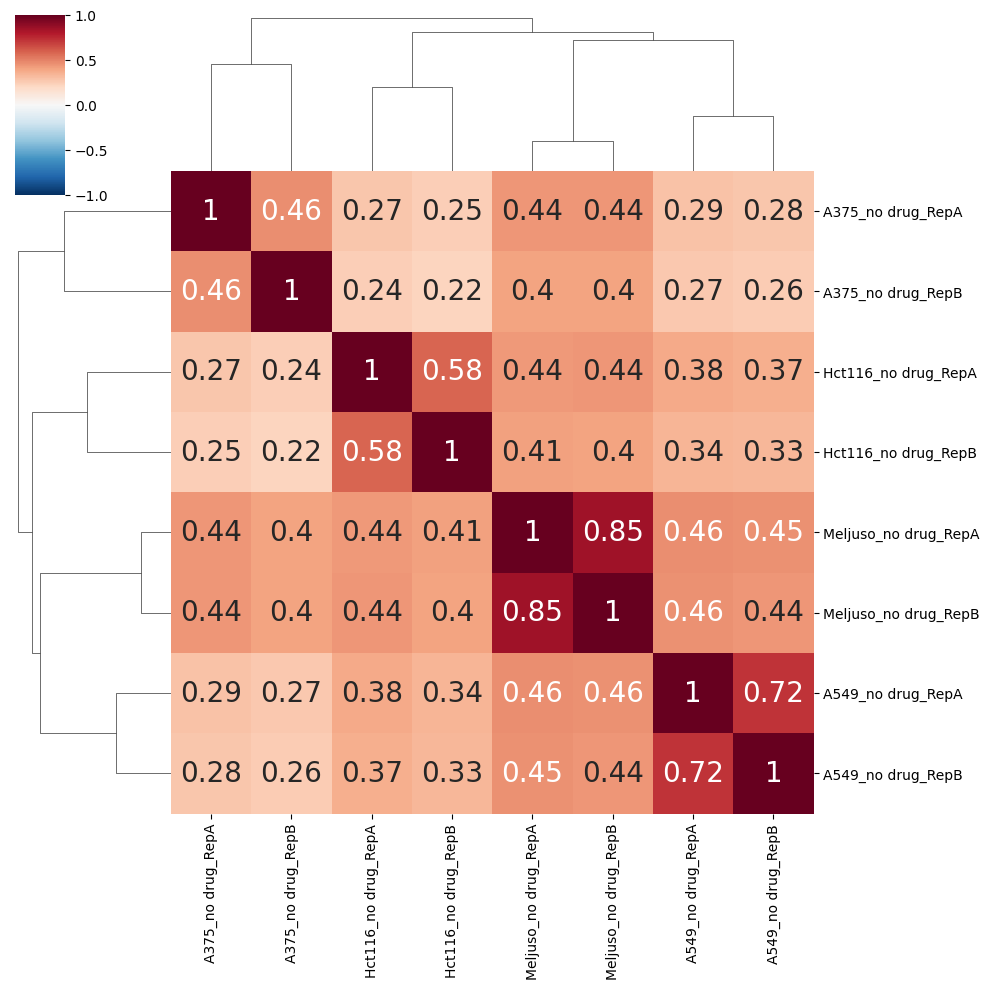

In [25]:
lfc_correlations = lfc_df.corr(numeric_only=True)
sns.clustermap(lfc_correlations, cmap='RdBu_r',
               vmin=-1, vmax=1, annot=True, annot_kws={"size": 20})
plt.savefig("output/plots/lfc_correlation_plot.png", dpi=300, bbox_inches="tight")

In [26]:
condition_map = {'A375_no drug_RepA': 'A375', 
                 'A375_no drug_RepB': 'A375', 
                 'Meljuso_no drug_RepA': 'Meljuso',
                 'Meljuso_no drug_RepB': 'Meljuso',
                 'A549_no drug_RepA' : "A549",
                 'A549_no drug_RepB': "A549",
                'Hct116_no drug_RepA' : "Hct116", 
                 'Hct116_no drug_RepB':"Hct116"
                }

In [27]:
long_lfcs = (lfc_df.melt(id_vars='sgRNA Sequence',
                         var_name='condition', value_name='lfc'))
long_lfcs

,sgRNA Sequence,condition,lfc
0,AAAAAAAAAAAGCACTCTGT,A375_no drug_RepA,-0.493709
1,AAAAAAAAAAGCAGTGGGAG,A375_no drug_RepA,0.371541
2,AAAAAAAAAAGGTCATTCAG,A375_no drug_RepA,-0.103722
3,AAAAAAAAAATGTCAGAAGC,A375_no drug_RepA,-0.557708
4,AAAAAAAAACAGGTCACCCA,A375_no drug_RepA,-0.421225
...,...,...,...
449123,TTTGTTTGCTTCGAGGACGA,Hct116_no drug_RepB,-0.164716
449124,TTTTACCTTGTTCACATGGA,Hct116_no drug_RepB,0.206667
449125,TTTTGACTCTAATCACCGGT,Hct116_no drug_RepB,-0.221947
449126,TTTTTAATACAAGGTAATCT,Hct116_no drug_RepB,0.116919


In [28]:
long_lfcs['condition'] = long_lfcs['condition'].map(condition_map)
avg_lfcs = (long_lfcs.groupby(['sgRNA Sequence', 'condition'])
            .agg(avg_lfc = ('lfc', 'mean'),
                 n_obs = ('lfc', 'count'))
            .reset_index())
avg_lfcs

,sgRNA Sequence,condition,avg_lfc,n_obs
0,AAAAAAAAAAAGCACTCTGT,A375,0.536648,2
1,AAAAAAAAAAAGCACTCTGT,A549,-0.003945,2
2,AAAAAAAAAAAGCACTCTGT,Hct116,-0.827478,2
3,AAAAAAAAAAAGCACTCTGT,Meljuso,0.375222,2
4,AAAAAAAAAAGCAGTGGGAG,A375,0.088336,2
...,...,...,...,...
224559,TTTTTAATACAAGGTAATCT,Meljuso,0.481982,2
224560,TTTTTCTCACCCGATGAATC,A375,0.662435,2
224561,TTTTTCTCACCCGATGAATC,A549,0.057713,2
224562,TTTTTCTCACCCGATGAATC,Hct116,0.028930,2


## Merge with annotations

In [29]:
annotated_sgrna_lfcs = (avg_lfcs.merge(annotation_file.rename({'Target Sequence': 'sgRNA Sequence'}, axis=1),
                                       how='inner',
                                       on='sgRNA Sequence'))
annotated_sgrna_lfcs

,sgRNA Sequence,condition,avg_lfc,n_obs,Merged Gene_ID
0,AAAAAAAAAAAGCACTCTGT,A375,0.536648,2,ENSG00000256061
1,AAAAAAAAAAAGCACTCTGT,A375,0.536648,2,ENSG00000261771
2,AAAAAAAAAAAGCACTCTGT,A549,-0.003945,2,ENSG00000256061
3,AAAAAAAAAAAGCACTCTGT,A549,-0.003945,2,ENSG00000261771
4,AAAAAAAAAAAGCACTCTGT,Hct116,-0.827478,2,ENSG00000256061
...,...,...,...,...,...
273127,TTTTTAATACAAGGTAATCT,Meljuso,0.481982,2,INACTIVE_5T; NO_SITE (5 zeros)
273128,TTTTTCTCACCCGATGAATC,A375,0.662435,2,INACTIVE_5T; NO_SITE (3 zeros)
273129,TTTTTCTCACCCGATGAATC,A549,0.057713,2,INACTIVE_5T; NO_SITE (3 zeros)
273130,TTTTTCTCACCCGATGAATC,Hct116,0.028930,2,INACTIVE_5T; NO_SITE (3 zeros)


## sgRNA level z-scores

In [30]:
# use guides with one intergenic site as controls
control_sgrna_lfcs = (annotated_sgrna_lfcs[(annotated_sgrna_lfcs['Merged Gene_ID']
                                            .str.contains('ONE_INTERGENIC_SITE'))]
                      .reset_index(drop=True))
control_sgrna_lfcs

,sgRNA Sequence,condition,avg_lfc,n_obs,Merged Gene_ID
0,AAAAAACAAAACAGGAACTG,A375,-0.127536,2,ONE_INTERGENIC_SITE
1,AAAAAACAAAACAGGAACTG,A549,-0.043910,2,ONE_INTERGENIC_SITE
2,AAAAAACAAAACAGGAACTG,Hct116,-0.295633,2,ONE_INTERGENIC_SITE
3,AAAAAACAAAACAGGAACTG,Meljuso,0.430190,2,ONE_INTERGENIC_SITE
4,AAAAAATAGTGTTGAATGAG,A375,0.806884,2,ONE_INTERGENIC_SITE
...,...,...,...,...,...
9071,TTTGTCACAATGATAAGATT,Meljuso,0.992454,2,ONE_INTERGENIC_SITE
9072,TTTTACCTTGTTCACATGGA,A375,0.926383,2,INACTIVE_4T; ONE_INTERGENIC_SITE
9073,TTTTACCTTGTTCACATGGA,A549,0.052686,2,INACTIVE_4T; ONE_INTERGENIC_SITE
9074,TTTTACCTTGTTCACATGGA,Hct116,0.314890,2,INACTIVE_4T; ONE_INTERGENIC_SITE


In [31]:
control_sgrna_stats = (control_sgrna_lfcs.groupby('condition')
                       .agg(neg_ctl_mean = ('avg_lfc', 'mean'),
                            neg_ctl_sd = ('avg_lfc', 'std'))
                       .reset_index())
control_sgrna_stats

,condition,neg_ctl_mean,neg_ctl_sd
0,A375,-0.160081,0.778883
1,A549,-0.052587,0.534344
2,Hct116,-0.083681,0.674035
3,Meljuso,-0.080200,0.913615


In [32]:
zscored_sgrna_lfcs = annotated_sgrna_lfcs.copy()
zscored_sgrna_lfcs = (zscored_sgrna_lfcs.merge(control_sgrna_stats,
                                               how='inner', on='condition'))
zscored_sgrna_lfcs['z_scored_avg_lfc'] = ((zscored_sgrna_lfcs['avg_lfc'] - zscored_sgrna_lfcs['neg_ctl_mean'])/
                                          zscored_sgrna_lfcs['neg_ctl_sd'])
zscored_sgrna_lfcs = zscored_sgrna_lfcs.drop(['neg_ctl_sd', 'neg_ctl_mean'], axis=1)
zscored_sgrna_lfcs

,sgRNA Sequence,condition,avg_lfc,n_obs,Merged Gene_ID,z_scored_avg_lfc
0,AAAAAAAAAAAGCACTCTGT,A375,0.536648,2,ENSG00000256061,0.894523
1,AAAAAAAAAAAGCACTCTGT,A375,0.536648,2,ENSG00000261771,0.894523
2,AAAAAAAAAAAGCACTCTGT,A549,-0.003945,2,ENSG00000256061,0.091031
3,AAAAAAAAAAAGCACTCTGT,A549,-0.003945,2,ENSG00000261771,0.091031
4,AAAAAAAAAAAGCACTCTGT,Hct116,-0.827478,2,ENSG00000256061,-1.103500
...,...,...,...,...,...,...
273127,TTTTTAATACAAGGTAATCT,Meljuso,0.481982,2,INACTIVE_5T; NO_SITE (5 zeros),0.615338
273128,TTTTTCTCACCCGATGAATC,A375,0.662435,2,INACTIVE_5T; NO_SITE (3 zeros),1.056019
273129,TTTTTCTCACCCGATGAATC,A549,0.057713,2,INACTIVE_5T; NO_SITE (3 zeros),0.206421
273130,TTTTTCTCACCCGATGAATC,Hct116,0.028930,2,INACTIVE_5T; NO_SITE (3 zeros),0.167070


## Gene level z-scores and statistics

In [33]:
zscored_gene_lfcs = (zscored_sgrna_lfcs.groupby(['Merged Gene_ID', 'condition'])
                     .agg(z_scored_lfc_sum = ('z_scored_avg_lfc', 'sum'), # sum of z_scored_avg_lfc per group
                          n_sgrnas = ('avg_lfc', 'count')) # count of avg_lfc = how many sgRNAs target that gene 
                     .reset_index())
zscored_gene_lfcs['z_scored_avg_lfc'] = (zscored_gene_lfcs['z_scored_lfc_sum']/np.sqrt(zscored_gene_lfcs['n_sgrnas'])) # gene level z score
zscored_gene_lfcs

,Merged Gene_ID,condition,z_scored_lfc_sum,n_sgrnas,z_scored_avg_lfc
0,ENSG00000000003,A375,1.403737,3,0.810448
1,ENSG00000000003,A549,0.041271,3,0.023828
2,ENSG00000000003,Hct116,-0.121878,3,-0.070367
3,ENSG00000000003,Meljuso,0.184529,3,0.106538
4,ENSG00000000005,A375,-2.109706,3,-1.218039
...,...,...,...,...,...
84995,ONE_INTERGENIC_SITE,Meljuso,-1.229340,2266,-0.025825
84996,POTENTIALLY_ACTIVE,A375,-59.491269,1327,-1.633119
84997,POTENTIALLY_ACTIVE,A549,-28.597465,1327,-0.785041
84998,POTENTIALLY_ACTIVE,Hct116,-82.128468,1327,-2.254542


In [34]:
#randomly sample controls to create pseudogenes, calculate aggregate z-score for each pseudogene
def get_pseudogene_distribution(df_with_guide_zscores,df_with_gene_zscores):
    #get guide-level z-scores of controls
    control_zscores= df_with_guide_zscores[df_with_guide_zscores["Merged Gene_ID"].isin(control_sgrna_lfcs["Merged Gene_ID"].tolist())].reset_index(drop=True)

    #num guides in each pseudogene is average num guides per gene in screen 
    num_guides_per_pseudogene= round(df_with_gene_zscores["n_sgrnas"].mean())
    
    random.seed(0)
    num_pseudogenes=1000
    control_pseudogene_zscores=[]
    for i in range(num_pseudogenes):
        #select n random indices from the list of control guides (n being the number of guides in a pseudogene)
        #sampling with replacement enables a more representative distribution, beneficial for small control set size
        control_guides_in_pseudogene=random.choices(range(len(control_zscores)), k=num_guides_per_pseudogene)
        control_pseudogene= control_zscores.loc[control_guides_in_pseudogene,:]
        #implements stouffers to calculate pseudogene-level z-score from z-score of each guide in pseudogene 
        control_pseudogene_zscores.append( control_pseudogene["z_scored_avg_lfc"].sum()/np.sqrt(num_guides_per_pseudogene))
    control_pseudogene_zscores.sort()
    return control_pseudogene_zscores

#calculate control pseudogene distribution separately for each condition
control_pseudogene_zscore_distribution_map={}
for condition in zscored_gene_lfcs["condition"].unique():
    control_pseudogene_zscore_distribution_map[condition]= get_pseudogene_distribution(zscored_sgrna_lfcs[zscored_sgrna_lfcs["condition"]==condition].reset_index(),zscored_gene_lfcs[zscored_gene_lfcs["condition"]==condition].reset_index())

def get_empirical_gene_pval(gene_level_z_score,condition):
    #use the control distribution that corresponds to the condition that the gene-level z-score is calculated from
    control_pseudogene_zscores= control_pseudogene_zscore_distribution_map[condition]
    #estimate probability distribution of pseudogene z-scores to get AUC for pval
    kde= scipy.stats.gaussian_kde(control_pseudogene_zscores)
    ha_less=kde.integrate_box_1d(-np.inf, gene_level_z_score)
    ha_greater=kde.integrate_box_1d(gene_level_z_score, np.inf)
    strongest_p_val=np.min([ha_less,ha_greater])
    return strongest_p_val

zscored_gene_lfcs['pval'] = zscored_gene_lfcs.apply(lambda x: get_empirical_gene_pval(x.z_scored_avg_lfc,x.condition),axis=1)
zscored_gene_lfcs

,Merged Gene_ID,condition,z_scored_lfc_sum,n_sgrnas,z_scored_avg_lfc,pval
0,ENSG00000000003,A375,1.403737,3,0.810448,0.220682
1,ENSG00000000003,A549,0.041271,3,0.023828,0.492275
2,ENSG00000000003,Hct116,-0.121878,3,-0.070367,0.468104
3,ENSG00000000003,Meljuso,0.184529,3,0.106538,0.489442
4,ENSG00000000005,A375,-2.109706,3,-1.218039,0.110019
...,...,...,...,...,...,...
84995,ONE_INTERGENIC_SITE,Meljuso,-1.229340,2266,-0.025825,0.431649
84996,POTENTIALLY_ACTIVE,A375,-59.491269,1327,-1.633119,0.053840
84997,POTENTIALLY_ACTIVE,A549,-28.597465,1327,-0.785041,0.221320
84998,POTENTIALLY_ACTIVE,Hct116,-82.128468,1327,-2.254542,0.021671


In [35]:
zscored_gene_lfcs=zscored_gene_lfcs.sort_values(by="condition")
zscored_gene_lfcs_agg_by_condition=zscored_gene_lfcs.groupby("condition").agg(list).reset_index()
zscored_gene_lfcs_agg_by_condition["FDR"]=zscored_gene_lfcs_agg_by_condition["pval"].apply(lambda x: multipletests(x,method="fdr_bh")[1])
zscored_gene_lfcs["FDR"]= zscored_gene_lfcs_agg_by_condition["FDR"].explode().tolist()

In [36]:
zscored_gene_lfcs.loc[zscored_gene_lfcs["FDR"]< 0.001,"FDR"] = 0.001

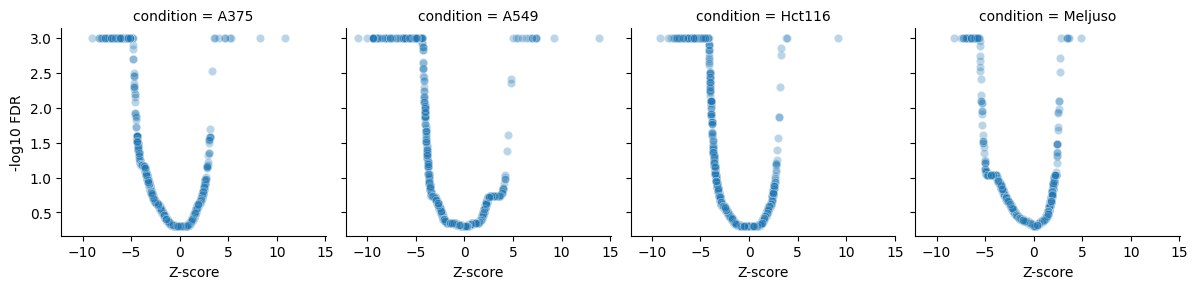

In [37]:
zscored_gene_lfcs['-log10 FDR'] = -np.log10(zscored_gene_lfcs['FDR']) 
g = sns.FacetGrid(data=zscored_gene_lfcs,
                  col='condition')
g.map_dataframe(sns.scatterplot, x='z_scored_avg_lfc', y='-log10 FDR',
                alpha=0.3)
sns.despine()
g.set_axis_labels(x_var='Z-score',
                  y_var='-log10 FDR')
plt.savefig("output/plots/volcano_plot.png", dpi=300, bbox_inches="tight")

In [38]:
zscored_gene_lfcs = zscored_gene_lfcs.sort_values(by='z_scored_avg_lfc')
zscored_gene_lfcs

,Merged Gene_ID,condition,z_scored_lfc_sum,n_sgrnas,z_scored_avg_lfc,pval,FDR,-log10 FDR
31265,ENSG00000142945,A549,-18.972385,3,-10.953712,8.997169e-184,0.001,3.0
2969,ENSG00000057657,A549,-17.413022,3,-10.053413,2.499700e-142,0.001,3.0
84493,ENSG00000308729,A549,-18.874334,4,-9.437167,4.188576e-117,0.001,3.0
75705,ENSG00000270629,A549,-18.874334,4,-9.437167,4.188576e-117,0.001,3.0
78913,ENSG00000286185,A549,-18.874334,4,-9.437167,4.188576e-117,0.001,3.0
...,...,...,...,...,...,...,...,...
73276,ENSG00000258471,A375,11.628412,2,8.222529,0.000000e+00,0.001,3.0
6334,ENSG00000085563,Hct116,15.777433,3,9.109105,0.000000e+00,0.001,3.0
84301,ENSG00000307699,A549,13.092600,2,9.257866,0.000000e+00,0.001,3.0
43780,ENSG00000165794,A375,18.687802,3,10.789408,0.000000e+00,0.001,3.0


## Identifying potential candidates

In [39]:
# considerations for candidate genes: 
# magnitude of viability effect (low median z score)
# minimizing false positives (low FDR) 
# consistency of effect size across cell lines (low median absolute deviation of z score)

# global_median = zscored_gene_lfcs['z_scored_avg_lfc'].median()
# global_mad = np.median(np.abs(zscored_gene_lfcs['z_scored_avg_lfc'] - global_median))
# zscored_gene_lfcs['global_mod_z'] = (0.6745 * (zscored_gene_lfcs['z_scored_avg_lfc'] - global_median)) / (global_mad + 1e-9)

gene_stats = zscored_gene_lfcs.groupby('Merged Gene_ID').agg(
    median_z=('z_scored_avg_lfc', 'median'),
    mad_z=('z_scored_avg_lfc', lambda x: np.median(np.abs(x - np.median(x)))), 
    max_fdr=('FDR', 'max'),
    # median_modified_z=('global_mod_z', 'median')
).reset_index()

# narrow down potential candidates
candidate_controls = gene_stats[
    (gene_stats['median_z'] < -3) & 
    (gene_stats['mad_z'] < 1.0) & 
    (gene_stats['max_fdr'] <= 0.001)
].copy()

In [40]:
# converting ENSEMBL IDs to gene symbols, add to df
mg = mygene.MyGeneInfo()
mg_df = pd.DataFrame(mg.querymany(candidate_controls['Merged Gene_ID'], scopes="ensemblgene", fields="symbol", species="human"))
mg_df = mg_df.rename(columns = {"query":"Merged Gene_ID"})

merged_candidate_df = pd.merge(candidate_controls, mg_df, on = "Merged Gene_ID")
merged_candidate_df = merged_candidate_df.drop(columns = {"_id","_score"})
merged_candidate_df = merged_candidate_df.sort_values('median_z') # use median z-score as ranking metric
merged_candidate_df.to_csv('output/candidate_pos_ctrls.csv', index=False)

In [41]:
merged_candidate_df

,Merged Gene_ID,median_z,mad_z,max_fdr,symbol
0,ENSG00000055332,-8.289833,0.032428,0.001,EIF2AK2
11,ENSG00000186185,-8.030524,0.544298,0.001,KIF18B
1,ENSG00000057657,-7.127153,0.519519,0.001,PRDM1
8,ENSG00000128383,-7.030102,0.081838,0.001,APOBEC3A
6,ENSG00000123080,-7.017378,0.449994,0.001,CDKN2C
7,ENSG00000124762,-7.012502,0.451484,0.001,CDKN1A
5,ENSG00000120889,-6.799594,0.883308,0.001,TNFRSF10B
4,ENSG00000104689,-6.461113,0.712139,0.001,TNFRSF10A
2,ENSG00000067066,-6.377602,0.548490,0.001,SP100
9,ENSG00000142731,-6.101141,0.836769,0.001,PLK4


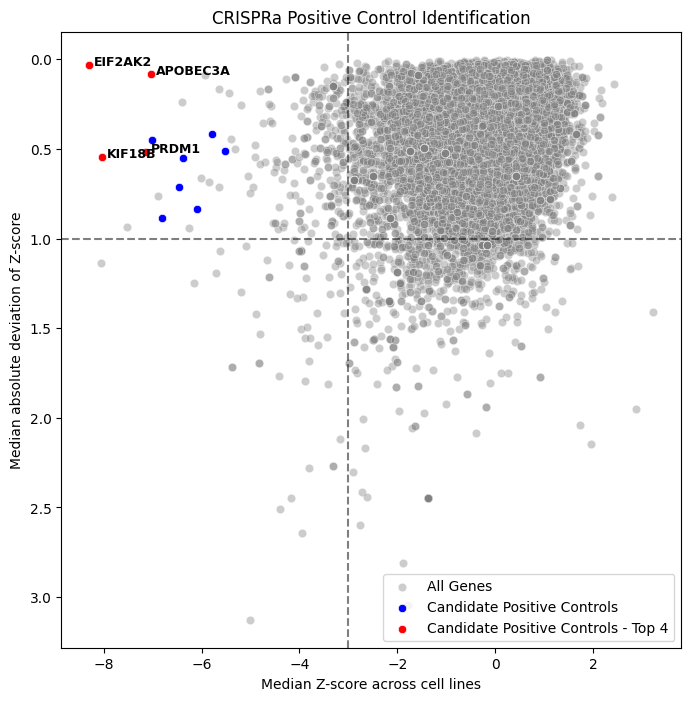

In [42]:
# add top 12
plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=gene_stats, 
    x='median_z', 
    y='mad_z', 
    alpha=0.4, 
    color='grey', 
    label='All Genes'
)

sns.scatterplot(
    data=merged_candidate_df,
    x='median_z', 
    y='mad_z', 
    color='blue', 
    label='Candidate Positive Controls'
)

sns.scatterplot(
    data=merged_candidate_df.head(4), # top four as candidates 
    x='median_z', 
    y='mad_z', 
    color='red', 
    label='Candidate Positive Controls - Top 4'
)

for _, row in merged_candidate_df.nsmallest(4, 'median_z').iterrows():
    plt.text(row['median_z'] + 0.1, row['mad_z'], row['symbol'], fontsize=9, weight='bold')

plt.axvline(x=-3, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Median Z-score across cell lines')
plt.ylabel('Median absolute deviation of Z-score')
plt.title('CRISPRa Positive Control Identification')
plt.gca().invert_yaxis() 
plt.legend()
plt.show
plt.savefig("output/plots/candidate_plot.png", dpi=300, bbox_inches="tight")

## Validation with STOP genes defined by Sack et al. 2018

In [57]:
filtered_stop_and_go = stop_and_go_gene_list[stop_and_go_gene_list['GeneSymbol'].isin(merged_candidate_df['symbol'])]
filtered_stop_and_go = filtered_stop_and_go[['GeneSymbol', 'Entrez GeneID', 
       'HMEC.Average.Log2FC.Drop', 'HMEC.Combined.pvalue.drop',
       'HMEC.FDR.drop', 
       'HPNE.Average.Log2.Drop', 'HPNE.Combined.pvalue.drop', 'HPNE.FDR.drop']]
filtered_stop_and_go.to_csv('output/subsetted_orf_screen.csv', index=False)
filtered_stop_and_go

,GeneSymbol,Entrez GeneID,HMEC.Average.Log2FC.Drop,HMEC.Combined.pvalue.drop,HMEC.FDR.drop,HPNE.Average.Log2.Drop,HPNE.Combined.pvalue.drop,HPNE.FDR.drop
3,CDKN2C,1031,-4.175,9.320000e-181,1.400000e-176,-4.277,2.830000e-68,4.260000e-64
8,CDKN1A,1026,-3.980,4.180000e-103,6.290000e-99,-4.289,3.910000e-46,5.890000e-42
636,SP100,6672,-1.390,1.630000e-14,2.370000e-10,-0.189,2.070000e-01,1.000000e+00
712,TNFRSF10B,8795,-1.260,2.000000e-03,1.000000e+00,-0.343,4.850000e-01,1.000000e+00
2591,TNFRSF10A,8797,-0.250,5.000000e-02,1.000000e+00,-0.734,4.600000e-02,1.000000e+00
8464,NDNF,79625,0.075,7.660000e-01,1.000000e+00,0.487,9.960000e-01,1.000000e+00
9083,EIF2AK2,5610,0.100,6.880000e-01,1.000000e+00,-0.137,4.940000e-01,1.000000e+00
14296,PRDM1,639,0.995,1.000000e+00,1.000000e+00,-2.487,1.970000e-11,2.930000e-07


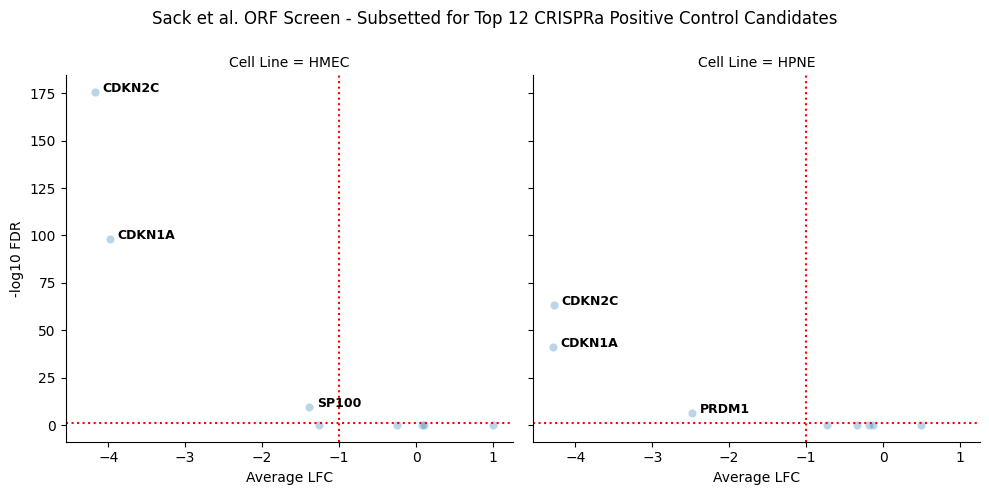

In [62]:
filtered_stop_and_go['HMEC -log10 FDR'] = -np.log10(filtered_stop_and_go['HMEC.FDR.drop'])
filtered_stop_and_go['HPNE -log10 FDR'] = -np.log10(filtered_stop_and_go['HPNE.FDR.drop'])

hmec_df = filtered_stop_and_go[['GeneSymbol', 'HMEC.Average.Log2FC.Drop', 'HMEC -log10 FDR']].copy()
hmec_df.columns = ['GeneSymbol', 'Average LFC', '-log10 FDR']
hmec_df['Cell Line'] = 'HMEC'

hpne_df = filtered_stop_and_go[['GeneSymbol', 'HPNE.Average.Log2.Drop', 'HPNE -log10 FDR']].copy()
hpne_df.columns = ['GeneSymbol', 'Average LFC', '-log10 FDR']
hpne_df['Cell Line'] = 'HPNE'

long_df = pd.concat([hmec_df, hpne_df], ignore_index=True)

g = sns.FacetGrid(data=long_df, col='Cell Line', sharex=True, sharey=True, height=5)
g.map_dataframe(sns.scatterplot, x='Average LFC', y='-log10 FDR', alpha=0.3)

def label_top_genes(data, **kwargs):
    ax = plt.gca()
    top_3 = data.nsmallest(3, 'Average LFC')
    for _, row in top_3.iterrows():
        ax.text(
            x = row['Average LFC'] + 0.1,  
            y = row['-log10 FDR'] - 0.1, 
            s = row['GeneSymbol'],                       
            fontsize=9,
            weight = 'bold'
        )

g.map_dataframe(label_top_genes)

sns.despine()
g.set_axis_labels(x_var='Average LFC', y_var='-log10 FDR')
g.fig.suptitle("Sack et al. ORF Screen - Subsetted for Top 12 CRISPRa Positive Control Candidates")
g.fig.subplots_adjust(top=0.85)
for ax in g.axes.flat:
    ax.axhline(y=1.3, color='red', linestyle=':')
    ax.axvline(x=-1, color='red', linestyle=':')
plt.savefig("output/plots/orf_volcano_plot.png", dpi=300, bbox_inches="tight")
plt.show()